# `screen_features.py`

Giai đoạn 6b (ds) — sàng lọc feature, chạy ĐỘC LẬP với de: tự tính lại toàn bộ feature lịch từ đầu bằng `lunardate` (không đọc file de sinh ra), rồi đối chiếu tương quan feature-target + phân tích dư thừa. Notebook unwrap nội dung hàm `main()` thành các cell tuần tự (dùng `textwrap.dedent`, không đổi logic), chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Downloads/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/screen_features.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from lunardate import LunarDate
from scipy import stats

warnings.filterwarnings("ignore", category=DeprecationWarning)

ROOT = Path(__file__).resolve().parents[2]
DATA_DIR = ROOT / "data"
OUT_DATA = Path(__file__).resolve().parent / "data"
OUT_CHART = ROOT / "EDA_Insight" / "output" / "phase6"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_CHART.mkdir(parents=True, exist_ok=True)

TREND_ORIGIN = pd.Timestamp("2012-07-04")  # ngày đầu tiên của sales.csv


## 1. Tết: tự tính bằng lunardate, KHÔNG đọc `tet_dates.csv` của phase1 hay de (hàm `build_tet_dates`, `compute_days_from_tet`, `build_features`)

In [3]:
def build_tet_dates(years: range) -> pd.DataFrame:
    rows = []
    for y in years:
        d = LunarDate(y, 1, 1).to_solar_date()
        rows.append({"year": y, "tet_date": pd.Timestamp(d)})
    return pd.DataFrame(rows)


def compute_days_from_tet(dates: pd.Series, tet_df: pd.DataFrame) -> pd.Series:
    """Số ngày có dấu tới Tết GẦN NHẤT (âm = trước Tết, dương = sau Tết).

    Với mỗi ngày, xét Tết năm đó và Tết năm liền kề (trước/sau), chọn Tết
    có |khoảng cách| nhỏ nhất -> đảm bảo liên tục qua ranh giới năm dương lịch.
    """
    tet_sorted = tet_df.sort_values("tet_date").reset_index(drop=True)
    tet_dates = tet_sorted["tet_date"].to_numpy()

    result = np.empty(len(dates), dtype="int64")
    dates_arr = pd.to_datetime(dates).to_numpy()
    idx_pos = np.searchsorted(tet_dates, dates_arr, side="left")

    for i, (d, pos) in enumerate(zip(dates_arr, idx_pos)):
        candidates = []
        for j in (pos - 1, pos, pos + 1):
            if 0 <= j < len(tet_dates):
                candidates.append(tet_dates[j])
        diffs = [(d - c) / np.timedelta64(1, "D") for c in candidates]
        best = min(diffs, key=lambda x: abs(x))
        result[i] = int(round(best))
    return pd.Series(result, index=dates.index)


VN_HOLIDAYS_FIXED = [
    (4, 30),
    (5, 1),
    (9, 2),
    (12, 25),
]


def build_features(dates: pd.Series, tet_df: pd.DataFrame) -> pd.DataFrame:
    dt = pd.to_datetime(dates)
    df = pd.DataFrame({"Date": dt})

    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["quarter"] = dt.dt.quarter
    df["day_of_week"] = dt.dt.weekday  # 0 = Thứ Hai
    df["day_of_month"] = dt.dt.day

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["is_post_2019"] = (dt >= pd.Timestamp("2019-01-01")).astype(int)
    df["is_post_2019_transition"] = (
        (dt >= pd.Timestamp("2019-01-01")) & (dt <= pd.Timestamp("2021-12-31"))
    ).astype(int)

    df["days_from_tet"] = compute_days_from_tet(df["Date"], tet_df)

    df["is_low_margin_season"] = df["month"].isin([7, 8, 9, 11, 12]).astype(int)

    df["trend_index"] = (dt - TREND_ORIGIN).dt.days

    is_holiday = pd.Series(False, index=df.index)
    for m, d in VN_HOLIDAYS_FIXED:
        is_holiday |= (df["month"] == m) & (df["day_of_month"] == d)
    df["is_vn_holiday"] = is_holiday.astype(int)

    return df

## 2. Load `sales.csv` (CHỈ ĐỌC), build feature cho đúng range train (hàm `load_sales`)

In [4]:
def load_sales() -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    return df

## Chạy pipeline (tương đương nội dung hàm `main()` — unwrap thành cell notebook bằng `textwrap.dedent`, KHÔNG đổi logic bên trong)

In [5]:
sales = load_sales()
print(f"[load] sales.csv: {sales.shape[0]} ngày, {sales['Date'].min().date()} -> {sales['Date'].max().date()}")

tet_df = build_tet_dates(range(2011, 2026))
tet_df.to_csv(OUT_DATA / "tet_dates_ds_check.csv", index=False)
print("\n[Tết tự tính bằng lunardate 2011-2025 — đối chiếu độc lập]")
print(tet_df.to_string(index=False))

feat = build_features(sales["Date"], tet_df)
feat = feat.merge(sales, on="Date", how="left")

[load] sales.csv: 3833 ngày, 2012-07-04 -> 2022-12-31

[Tết tự tính bằng lunardate 2011-2025 — đối chiếu độc lập]
 year   tet_date
 2011 2011-02-03
 2012 2012-01-23
 2013 2013-02-10
 2014 2014-01-31
 2015 2015-02-19
 2016 2016-02-08
 2017 2017-01-28
 2018 2018-02-16
 2019 2019-02-05
 2020 2020-01-25
 2021 2021-02-12
 2022 2022-02-01
 2023 2023-01-22
 2024 2024-02-10
 2025 2025-01-29


### Validate `days_from_tet` quanh vài mốc Tết (2019 trong train; 2023/2024 minh hoạ công thức, ngoài range train)

In [6]:
print("\n[Validate days_from_tet quanh Tết 2019 (2019-02-05)]")
mask = (feat["Date"] >= "2019-01-28") & (feat["Date"] <= "2019-02-12")
print(feat.loc[mask, ["Date", "days_from_tet"]].to_string(index=False))

print("\n[Validate days_from_tet quanh Tết 2023 (2023-01-22) — NGOÀI range train,"
      " chỉ minh hoạ công thức tự tính, không lấy từ sales.csv]")
tet_2023_window = pd.date_range("2023-01-15", "2023-01-29")
tmp = build_features(pd.Series(tet_2023_window), tet_df)
print(tmp[["Date", "days_from_tet"]].to_string(index=False))

print("\n[Validate days_from_tet quanh Tết 2024 (2024-02-10) — NGOÀI range train]")
tet_2024_window = pd.date_range("2024-02-03", "2024-02-17")
tmp2 = build_features(pd.Series(tet_2024_window), tet_df)
print(tmp2[["Date", "days_from_tet"]].to_string(index=False))

print("\n[Validate liên tục qua ranh giới năm dương lịch: 2019-12-25 -> 2020-01-05"
      " (giữa Tết 2019 (02-05) và Tết 2020 (01-25))]")
mask2 = (feat["Date"] >= "2019-12-25") & (feat["Date"] <= "2020-01-05")
print(feat.loc[mask2, ["Date", "days_from_tet"]].to_string(index=False))


[Validate days_from_tet quanh Tết 2019 (2019-02-05)]
      Date  days_from_tet
2019-01-28             -8
2019-01-29             -7
2019-01-30             -6
2019-01-31             -5
2019-02-01             -4
2019-02-02             -3
2019-02-03             -2
2019-02-04             -1
2019-02-05              0
2019-02-06              1
2019-02-07              2
2019-02-08              3
2019-02-09              4
2019-02-10              5
2019-02-11              6
2019-02-12              7

[Validate days_from_tet quanh Tết 2023 (2023-01-22) — NGOÀI range train, chỉ minh hoạ công thức tự tính, không lấy từ sales.csv]
      Date  days_from_tet
2023-01-15             -7
2023-01-16             -6
2023-01-17             -5
2023-01-18             -4
2023-01-19             -3
2023-01-20             -2
2023-01-21             -1
2023-01-22              0
2023-01-23              1
2023-01-24              2
2023-01-25              3
2023-01-26              4
2023-01-27              5
2023-01-28

### Sàng lọc tương quan feature-target (Pearson/Spearman)

In [7]:
numeric_cont = [
    "year", "month", "quarter", "day_of_week", "day_of_month",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "days_from_tet", "trend_index",
]
binary_feats = ["is_post_2019", "is_post_2019_transition", "is_low_margin_season", "is_vn_holiday"]

rows = []
for col in numeric_cont:
    for target in ["Revenue", "COGS"]:
        pear_r, pear_p = stats.pearsonr(feat[col], feat[target])
        spear_r, spear_p = stats.spearmanr(feat[col], feat[target])
        rows.append({
            "feature": col, "type": "continuous", "target": target,
            "pearson_r": round(pear_r, 4), "pearson_p": round(pear_p, 6),
            "spearman_r": round(spear_r, 4), "spearman_p": round(spear_p, 6),
            "group_mean_diff": np.nan,
        })

for col in binary_feats:
    for target in ["Revenue", "COGS"]:
        g1 = feat.loc[feat[col] == 1, target]
        g0 = feat.loc[feat[col] == 0, target]
        pear_r, pear_p = stats.pearsonr(feat[col], feat[target])
        spear_r, spear_p = stats.spearmanr(feat[col], feat[target])
        diff = g1.mean() - g0.mean()
        rows.append({
            "feature": col, "type": "binary", "target": target,
            "pearson_r": round(pear_r, 4), "pearson_p": round(pear_p, 6),
            "spearman_r": round(spear_r, 4), "spearman_p": round(spear_p, 6),
            "group_mean_diff": round(diff, 2),
        })

corr_df = pd.DataFrame(rows)
corr_df.to_csv(OUT_DATA / "feature_target_correlation.csv", index=False)
print("\n[Tương quan feature-target] (Pearson/Spearman, n=%d ngày, range train)" % len(feat))
print(corr_df.to_string(index=False))


[Tương quan feature-target] (Pearson/Spearman, n=3833 ngày, range train)
                feature       type  target  pearson_r  pearson_p  spearman_r  spearman_p  group_mean_diff
                   year continuous Revenue    -0.2776   0.000000     -0.3410    0.000000              NaN
                   year continuous    COGS    -0.2697   0.000000     -0.3281    0.000000              NaN
                  month continuous Revenue    -0.2043   0.000000     -0.2388    0.000000              NaN
                  month continuous    COGS    -0.1603   0.000000     -0.1822    0.000000              NaN
                quarter continuous Revenue    -0.2144   0.000000     -0.2482    0.000000              NaN
                quarter continuous    COGS    -0.1745   0.000000     -0.1975    0.000000              NaN
            day_of_week continuous Revenue    -0.0670   0.000033     -0.0735    0.000005              NaN
            day_of_week continuous    COGS    -0.0668   0.000035     -0.0765  

### Chart minh hoạ sàng lọc (heatmap tương quan Pearson)

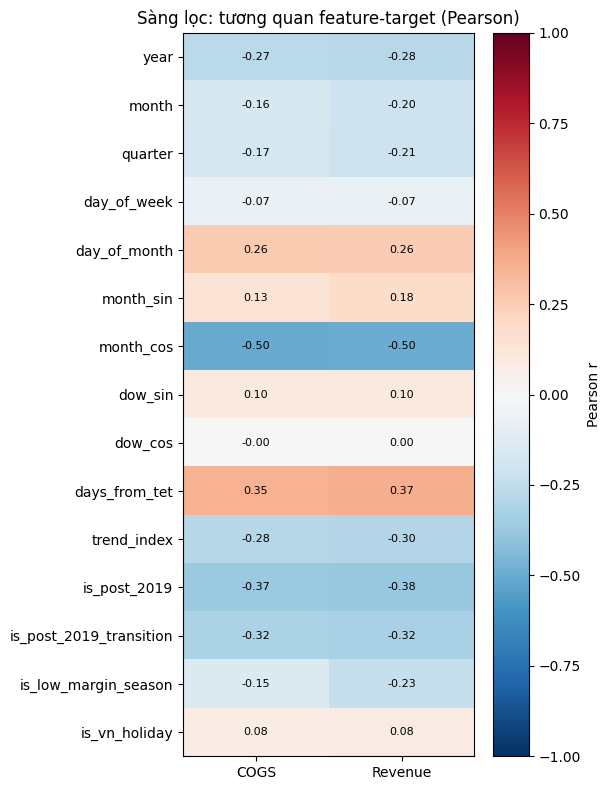


[chart] /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/output/phase6/screen_feature_target_corr_heatmap.png


In [8]:
try:
    import matplotlib.pyplot as plt

    pivot = corr_df.pivot_table(index="feature", columns="target", values="pearson_r")
    pivot = pivot.reindex(numeric_cont + binary_feats)
    fig, ax = plt.subplots(figsize=(6, 8))
    im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Pearson r")
    ax.set_title("Sàng lọc: tương quan feature-target (Pearson)")
    fig.tight_layout()
    fig.savefig(OUT_CHART / "screen_feature_target_corr_heatmap.png", dpi=120)
    plt.show()
    plt.close(fig)
    print(f"\n[chart] {OUT_CHART / 'screen_feature_target_corr_heatmap.png'}")
except ImportError:
    print("\n[chart] matplotlib không có sẵn, bỏ qua bước vẽ chart (không bắt buộc).")

### Phân tích dư thừa (redundancy) — tương quan chéo month vs quarter vs month_sin/cos

In [9]:
print("\n[Redundancy check] tương quan chéo month vs quarter vs month_sin/cos")
redundancy_cols = ["month", "quarter", "month_sin", "month_cos", "day_of_month", "trend_index", "year", "is_post_2019"]
red_corr = feat[redundancy_cols].corr(method="spearman").round(3)
red_corr.to_csv(OUT_DATA / "redundancy_correlation_matrix.csv")
print(red_corr.to_string())


[Redundancy check] tương quan chéo month vs quarter vs month_sin/cos
              month  quarter  month_sin  month_cos  day_of_month  trend_index   year  is_post_2019
month         1.000    0.971     -0.756      0.207         0.011        0.023 -0.069        -0.033
quarter       0.971    1.000     -0.776      0.204         0.013        0.019 -0.070        -0.033
month_sin    -0.756   -0.776      1.000     -0.002        -0.009       -0.001  0.068         0.032
month_cos     0.207    0.204     -0.002      1.000        -0.003        0.002 -0.015        -0.007
day_of_month  0.011    0.013     -0.009     -0.003         1.000        0.006 -0.003        -0.001
trend_index   0.023    0.019     -0.001      0.002         0.006        1.000  0.996         0.841
year         -0.069   -0.070      0.068     -0.015        -0.003        0.996  1.000         0.845
is_post_2019 -0.033   -0.033      0.032     -0.007        -0.001        0.841  0.845         1.000


### Hoàn tất

In [10]:
print("\nHoàn tất. File output:")
print(f" - {OUT_DATA / 'feature_target_correlation.csv'}")
print(f" - {OUT_DATA / 'redundancy_correlation_matrix.csv'}")
print(f" - {OUT_DATA / 'tet_dates_ds_check.csv'}")


Hoàn tất. File output:
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/data/feature_target_correlation.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/data/redundancy_correlation_matrix.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/data/tet_dates_ds_check.csv
